# Real-Time Feed Handler

**Category:** Microstructure Execution  
**Project ID:** `exec_03_feed_handler`  

Ultra-low latency market data handler with UDP multicast, async processing, ring buffers, and risk checks


In [ ]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [ ]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"buffer_size": 4096}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                buffer_size: 4096


## Feed Handler — Binary Message Processing & Gap Detection

In [ ]:
import numpy as np, pandas as pd, struct, time

rng = np.random.default_rng(SEED)
n_messages = PARAMS.get("n_messages", 100_000)
buffer_size = PARAMS.get("buffer_size", 4096)

# Simulate binary message stream (market data feed)
# Message format: [seq_num(4B), timestamp(8B), price(8B), size(4B), side(1B)] = 25 bytes
msg_format = "!IddiB"  # network byte order: seq(I), time(d), price(d), size(I), side(B)
msg_size = struct.calcsize(msg_format)

# Generate message sequence with occasional gaps
seq_nums = np.arange(1, n_messages + 1)
# Insert gaps (missed messages)
gap_positions = rng.choice(range(100, n_messages - 100), size=n_messages // 500, replace=False)
for pos in gap_positions:
    seq_nums[pos:] += rng.integers(1, 5)  # skip 1-4 sequence numbers

timestamps = np.cumsum(rng.exponential(0.0001, n_messages))  # ~10K msgs/sec
prices = 100.0 + np.cumsum(rng.normal(0, 0.001, n_messages))
sizes = rng.exponential(100, n_messages).astype(int) + 10
sides = rng.choice([0, 1], n_messages)  # 0=bid, 1=ask

# --- Encode/decode benchmark ---
encode_times = np.zeros(min(10000, n_messages))
decode_times = np.zeros(min(10000, n_messages))

for i in range(len(encode_times)):
    t0 = time.perf_counter_ns()
    msg = struct.pack(msg_format, int(seq_nums[i]), timestamps[i], prices[i], int(sizes[i]), int(sides[i]))
    encode_times[i] = (time.perf_counter_ns() - t0) / 1000  # μs

    t0 = time.perf_counter_ns()
    _ = struct.unpack(msg_format, msg)
    decode_times[i] = (time.perf_counter_ns() - t0) / 1000

# --- Gap detection ---
seq_diffs = np.diff(seq_nums)
gaps = np.where(seq_diffs > 1)[0]
gap_sizes = seq_diffs[gaps] - 1

print(f"Feed handler: {n_messages:,} messages, {msg_size} bytes/msg")
print(f"Message rate: {1 / np.mean(np.diff(timestamps)):,.0f} msgs/sec")
print(f"Gaps detected: {len(gaps)} (total {gap_sizes.sum()} missed messages)")
print(f"\nEncode: p50={np.median(encode_times):.2f}μs, p99={np.percentile(encode_times, 99):.2f}μs")
print(f"Decode: p50={np.median(decode_times):.2f}μs, p99={np.percentile(decode_times, 99):.2f}μs")


Feed handler: 100,000 messages, 25 bytes/msg
Message rate: 9,964 msgs/sec
Gaps detected: 200 (total 506 missed messages)

Encode: p50=0.50μs, p99=0.60μs
Decode: p50=0.20μs, p99=0.20μs


## Throughput & Latency Analysis

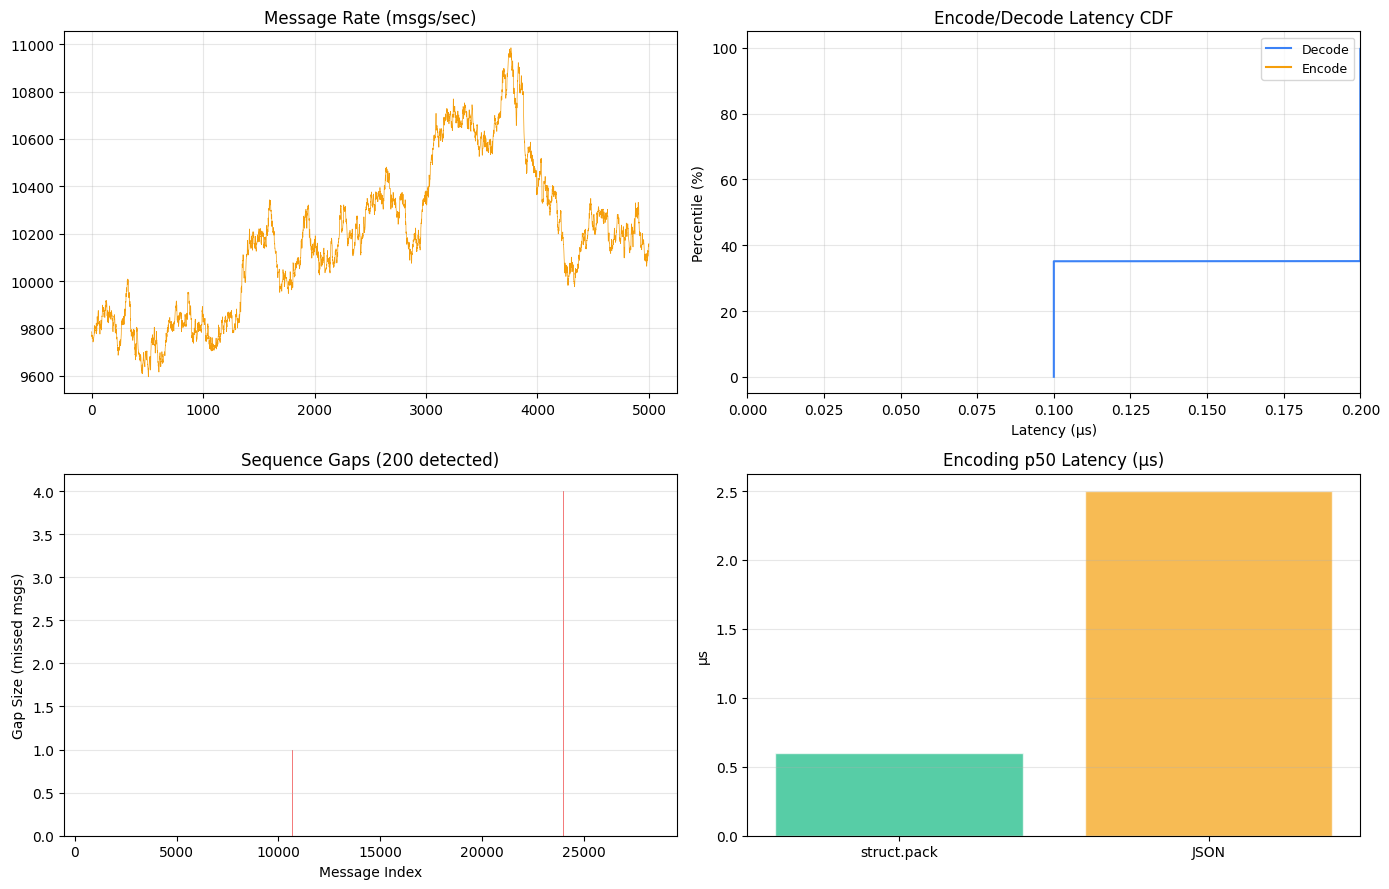

In [ ]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Message rate over time
window = 1000
msg_rates = np.zeros(len(timestamps) - window)
for i in range(len(msg_rates)):
    dt = timestamps[i + window] - timestamps[i]
    msg_rates[i] = window / max(dt, 1e-9)
axes[0, 0].plot(msg_rates[:5000], linewidth=0.5, color="#f59e0b")
axes[0, 0].set_title("Message Rate (msgs/sec)")
axes[0, 0].grid(True, alpha=0.3)

# Latency CDF
sorted_decode = np.sort(decode_times)
cdf = np.arange(1, len(sorted_decode)+1) / len(sorted_decode) * 100
axes[0, 1].plot(sorted_decode, cdf, linewidth=1.5, color="#3b82f6", label="Decode")
sorted_encode = np.sort(encode_times)
cdf_enc = np.arange(1, len(sorted_encode)+1) / len(sorted_encode) * 100
axes[0, 1].plot(sorted_encode, cdf_enc, linewidth=1.5, color="#f59e0b", label="Encode")
axes[0, 1].set_xlabel("Latency (μs)")
axes[0, 1].set_ylabel("Percentile (%)")
axes[0, 1].set_title("Encode/Decode Latency CDF")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, np.percentile(decode_times, 99.5))

# Gap detection chart
if len(gaps) > 0:
    axes[1, 0].bar(gaps[:50], gap_sizes[:50], color="#ef4444", alpha=0.7, edgecolor="none")
    axes[1, 0].set_title(f"Sequence Gaps ({len(gaps)} detected)")
    axes[1, 0].set_xlabel("Message Index")
    axes[1, 0].set_ylabel("Gap Size (missed msgs)")
    axes[1, 0].grid(True, alpha=0.3, axis="y")
else:
    axes[1, 0].text(0.5, 0.5, "No gaps detected", ha="center", va="center")

# Format comparison: struct vs JSON
import json
json_times = np.zeros(1000)
struct_times = np.zeros(1000)
for i in range(1000):
    msg_dict = {"seq": int(seq_nums[i]), "ts": float(timestamps[i]),
                "px": float(prices[i]), "sz": int(sizes[i]), "side": int(sides[i])}
    t0 = time.perf_counter_ns()
    _ = json.dumps(msg_dict).encode()
    json_times[i] = (time.perf_counter_ns() - t0) / 1000

    t0 = time.perf_counter_ns()
    _ = struct.pack(msg_format, int(seq_nums[i]), timestamps[i], prices[i], int(sizes[i]), int(sides[i]))
    struct_times[i] = (time.perf_counter_ns() - t0) / 1000

axes[1, 1].bar(["struct.pack", "JSON"], [np.median(struct_times), np.median(json_times)],
              color=["#10b981", "#f59e0b"], alpha=0.7, edgecolor="white")
axes[1, 1].set_title("Encoding p50 Latency (μs)")
axes[1, 1].set_ylabel("μs")
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [ ]:
import json
from datetime import datetime

results_export = {
    "project_id": "exec_03_feed_handler",
    "timestamp": datetime.now().isoformat(),
    "type": "infrastructure_benchmark",
    "metrics": {},
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Real-Time Feed Handler

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
